<a href="https://colab.research.google.com/github/toshi039a/retail-demand-forecast/blob/main/%E9%9B%A2%E8%84%B1%E4%BA%88%E6%B8%ACPF_20260502.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EC顧客データを用いた離脱予測モデル構築

## 1. 概要とデータ読み込み

本分析では、Kaggleの「Ecommerce Customer Churn Analysis and Prediction」データセットを使用する。

本データは、ECサービスにおける顧客属性・利用状況・購買行動に関するデータであり、顧客が離脱するかどうかを予測することを目的とする。

顧客離脱予測は、既存顧客の維持・売上の機会損失防止・マーケティング施策の最適化において重要な分析テーマである。  
離脱リスクの高い顧客を事前に把握できれば、クーポン配布、サポート強化、利用促進施策などの打ち手につなげることができる。

なお、本データセットでは `Churn` は顧客離脱フラグとして提供されているが、離脱の具体的な定義は明記されていない。  
そのため、本分析では `Churn=1` を「ECサービスから離脱したと判定された顧客」、`Churn=0` を「継続顧客」として扱う。

本Notebookでは、以下の流れで離脱予測モデルを構築する。

1. 概要とデータ読み込み
2. 探索的データ分析（EDA）
3. 前処理と特徴量整理
4. モデリング・評価・モデル解釈
5. 閾値調整と施策提案
6. まとめ

### 1.1 データ構造の確認

まずは、データの行数・列数・カラムの型、欠損値の有無を確認する。

本データは顧客単位のデータであり、1行が1顧客を表す。  
目的変数は `Churn` であり、その他のカラムには顧客属性・利用状況・購買行動等に関する情報が含まれている。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 本分析ではKaggleの「Ecommerce Customer Churn Analysis and Prediction」を使用した。
# ECサービスの顧客属性・利用状況・購買行動に関するデータであり、
# 顧客が離脱するかどうかを予測する二値分類問題として扱う。
# データは以下から取得可能である。
# https://www.kaggle.com/datasets/ankitverma2010/ecommerce-customer-churn-analysis-and-prediction

from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/離脱予測PF/E Commerce Dataset.xlsx'

df = pd.read_excel(file_path, sheet_name='E Comm')
data_dict = pd.read_excel(file_path, sheet_name='Data Dict')

df.head()

Mounted at /content/drive


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

データは5,630行・20列で構成されている。  
数値変数とカテゴリ変数が混在しており、一部の数値変数には欠損値が存在する。

特に、以下のようなカラムに欠損値が確認される。

- `Tenure`
- `WarehouseToHome`
- `HourSpendOnApp`
- `OrderAmountHikeFromlastYear`
- `CouponUsed`
- `OrderCount`
- `DaySinceLastOrder`

これらの欠損値については、後続の前処理で適切に処理する。

### 1.2 カラム定義の確認

`Data Dict` シートには、各カラムの説明が記載されている。  
EDAやモデル解釈を行う前に、各変数の意味を確認する。

In [3]:
data_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


本分析で特に重要と思われる主なカラムは以下の通りである。

- `Churn`：顧客離脱フラグ
- `Tenure`：顧客の利用期間
- `SatisfactionScore`：満足度スコア
- `Complain`：クレーム有無
- `OrderCount`：直近月の注文回数
- `DaySinceLastOrder`：最終注文からの日数
- `CashbackAmount`：キャッシュバック金額

なお、`CustomerID` は顧客識別用のIDであり、予測に直接使用しない。

### 1.3 目的変数の確認

本分析の目的変数である `Churn` の分布を確認する。

離脱予測では、離脱顧客が継続顧客より少ないケースが多いため、まずはクラス比率を確認する。  

In [4]:
# 目的変数の件数確認
df['Churn'].value_counts()

,count
Churn,
0,4682
1,948


In [5]:
# 離脱率の確認
churn_rate = df['Churn'].mean()

print(f'離脱率: {churn_rate:.2%}')

離脱率: 16.84%


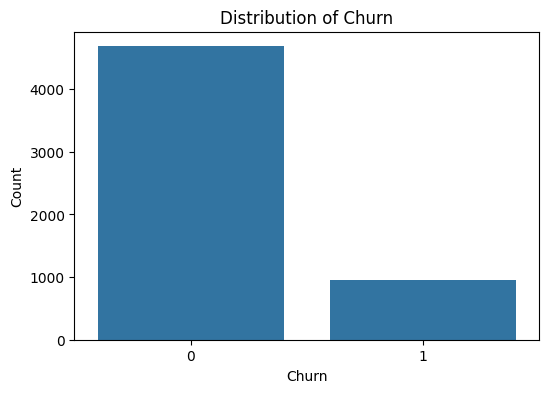

In [6]:
# Churnの分布を可視化
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn')
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

- `Churn` の分布を確認したところ、離脱率は16.84%であり、継続顧客が多数を占めている。

- このことから、本データはクラス不均衡を含む二値分類問題であると考えられる。
- クラス不均衡がある場合、Accuracyだけでは少数派である離脱顧客の検出性能を適切に評価できないため、後続のモデル評価ではRecallやPrecision、PR-AUCなども重視する。

### 1.4 欠損値の詳細確認

`df.info()` により、一部の数値変数に欠損値が存在することが確認された。

ここでは、各カラムの欠損数と欠損率を確認し、後続の前処理方針を検討する。

In [7]:
# 欠損数と欠損率を確認
missing_df = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_rate': df.isna().mean()
}).sort_values('missing_count', ascending=False)

# 欠損値があるカラムのみ表示
missing_df = missing_df[missing_df['missing_count'] > 0].copy()
missing_df

,missing_count,missing_rate
DaySinceLastOrder,307,0.054529
OrderAmountHikeFromlastYear,265,0.047069
Tenure,264,0.046892
OrderCount,258,0.045826
CouponUsed,256,0.045471
HourSpendOnApp,255,0.045293
WarehouseToHome,251,0.044583


- 欠損値を確認したところ、7つの数値変数に欠損が存在していることが分かった。
- 最も欠損が多い `DaySinceLastOrder` でも欠損率は5.45%であり、全体として欠損率は高くない。
- 欠損率が極端に高いカラムはないため、後続の前処理ではカラム削除ではなく中央値での補完によって対応する方針とする。

### 1.5 数値変数・カテゴリ変数の整理

モデル構築に向けて、数値変数とカテゴリ変数を整理する。

In [8]:
# 数値変数の抽出
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['CustomerID',
 'Churn',
 'Tenure',
 'CityTier',
 'WarehouseToHome',
 'HourSpendOnApp',
 'NumberOfDeviceRegistered',
 'SatisfactionScore',
 'NumberOfAddress',
 'Complain',
 'OrderAmountHikeFromlastYear',
 'CouponUsed',
 'OrderCount',
 'DaySinceLastOrder',
 'CashbackAmount']

In [9]:
# 文字列型カテゴリ変数の抽出
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

cat_cols

['PreferredLoginDevice',
 'PreferredPaymentMode',
 'Gender',
 'PreferedOrderCat',
 'MaritalStatus']

In [10]:
# 文字列型カテゴリ変数のユニーク数確認
df[cat_cols].nunique()

,0
PreferredLoginDevice,3
PreferredPaymentMode,7
Gender,2
PreferedOrderCat,6
MaritalStatus,3


In [11]:
# 各文字列型カテゴリ変数の値を確認
for col in cat_cols:
    print(f'【{col}】')
    print(df[col].value_counts(dropna=False))
    print('-' * 50)

【PreferredLoginDevice】
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
--------------------------------------------------
【PreferredPaymentMode】
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
--------------------------------------------------
【Gender】
Gender
Male      3384
Female    2246
Name: count, dtype: int64
--------------------------------------------------
【PreferedOrderCat】
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
--------------------------------------------------
【MaritalStatus】
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64
---------------

- 文字列型のカテゴリ変数として、ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況が含まれていることを確認した。
- これらのカテゴリ変数はいずれもユニーク数が多すぎず、後続の前処理ではOne-Hot Encodingで扱いやすい構成である。
- `SatisfactionScore` や `CityTier` は数値型として読み込まれているが、連続量というよりも評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面がある。
- そのため、後続の前処理では、モデルの性質に応じて数値変数として扱うか、カテゴリ変数として扱うかを検討する。
- `PreferredLoginDevice` では `Mobile Phone` と `Phone`、`PreferredPaymentMode` では `Credit Card` と `CC`、`COD` と `Cash on Delivery` のように、意味が近いと思われるカテゴリが存在している。
- ただし、本データセット上でこれらが完全に同一カテゴリであるとは明記されていないため、本分析では元データのカテゴリを大きく加工せず、前処理でエンコーディングを行う方針とする。
- 実務では、これらが同一カテゴリかどうかをデータ定義や業務担当者への確認によって判断し、必要に応じて表記ゆれの統一を行う。
- `CustomerID` は顧客識別用のIDであり、予測に直接使用しない。
- `Churn` は目的変数であるため、説明変数からは除外する。

## 2. 探索的データ分析（EDA）

ここでは、目的変数である `Churn` と各説明変数の関係を確認する。

特に、以下の観点から離脱傾向を把握する。

1. 利用期間と離脱率の関係
2. 満足度スコアと離脱率の関係
3. クレーム有無と離脱率の関係
4. 注文回数と離脱率の関係
5. 最終注文からの日数と離脱率の関係
6. カテゴリ変数ごとの離脱率
7. 数値変数同士の相関

EDAを通じて、どのような顧客が離脱しやすい傾向にあるかを把握し、後続のモデル構築や施策提案につなげる。

### 2.1 利用期間と離脱率の関係

顧客の利用期間を表す `Tenure` と離脱率の関係を確認する。

一般的に、利用期間が短い顧客はサービスへの定着度が低く、離脱しやすい可能性がある。  
一方で、利用期間が長い顧客は継続利用の傾向が強いと考えられる。

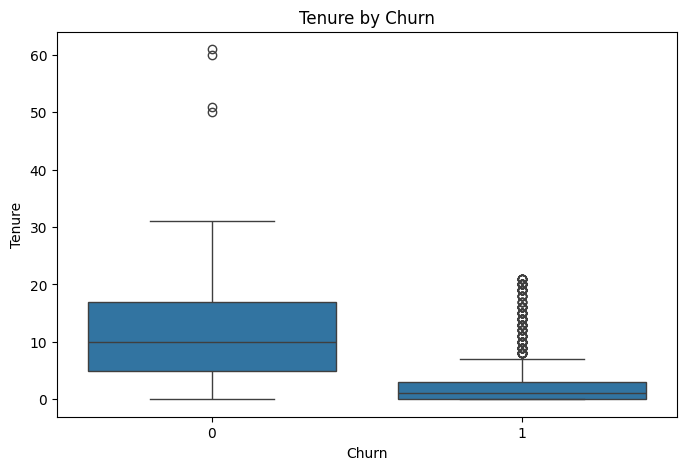

In [12]:
# Churn別にTenureの分布を確認
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Tenure')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.show()

In [13]:
# Tenureを各区間に分ける
df['Tenure_bin'] = pd.cut(
    df['Tenure'],
    bins=[0, 3, 6, 12, 24, np.inf],
    labels=['0-3', '4-6', '7-12', '13-24', '25+'],
    include_lowest=True
)

# Tenure区間ごとの離脱率と件数を集計
tenure_churn = df.groupby('Tenure_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

tenure_churn

,Tenure_bin,churn_rate,count
0,0-3,0.418590,1560
1,4-6,0.074576,590
2,7-12,0.056818,1320
3,13-24,0.064758,1467
4,25+,0.000000,429


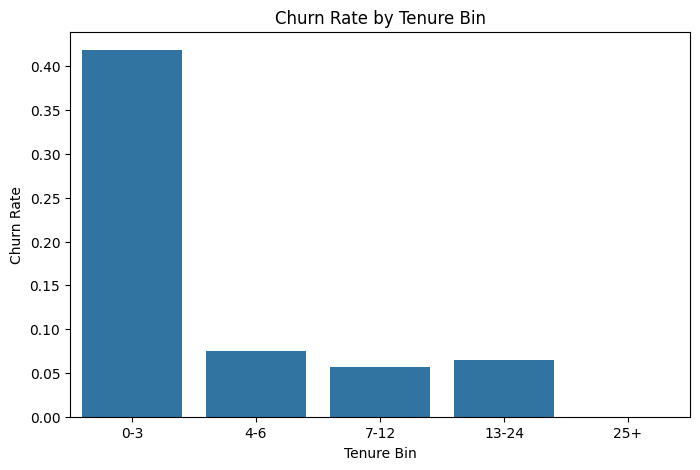

In [14]:
# 各Tenure区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=tenure_churn, x='Tenure_bin', y='churn_rate')
plt.title('Churn Rate by Tenure Bin')
plt.xlabel('Tenure Bin')
plt.ylabel('Churn Rate')
plt.show()

- `Tenure` を区間ごとに分けて離脱率を確認した。
- 利用期間が `0-3` の顧客では離脱率が約41.9%と高く、利用開始初期の顧客ほど離脱しやすい傾向が見られる。
- 一方で、`4-6` 以降の区間では離脱率が大きく低下しており、一定期間利用を継続した顧客は離脱しにくくなる傾向がある。
- `25+` の区間では、このデータ上では離脱率が0%となっている。（ただし、区間ごとの件数にも差があるため、離脱率だけでなく件数も確認しながら解釈する必要がある）
- この結果から、`Tenure` は離脱予測において重要な特徴量となる可能性がある。
- 実務においては、利用開始初期の顧客に対するオンボーディング施策や利用促進施策が離脱防止に有効である可能性がある。

### 2.2 満足度スコアと離脱率の関係

サービス評価に関するスコアである `SatisfactionScore` と離脱率の関係を確認する。

In [15]:
# SatisfactionScoreごとの離脱率と件数を集計
satisfaction_churn = df.groupby('SatisfactionScore').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

satisfaction_churn

,SatisfactionScore,churn_rate,count
0,1,0.115120,1164
1,2,0.126280,586
2,3,0.171967,1698
3,4,0.171322,1074
4,5,0.238267,1108


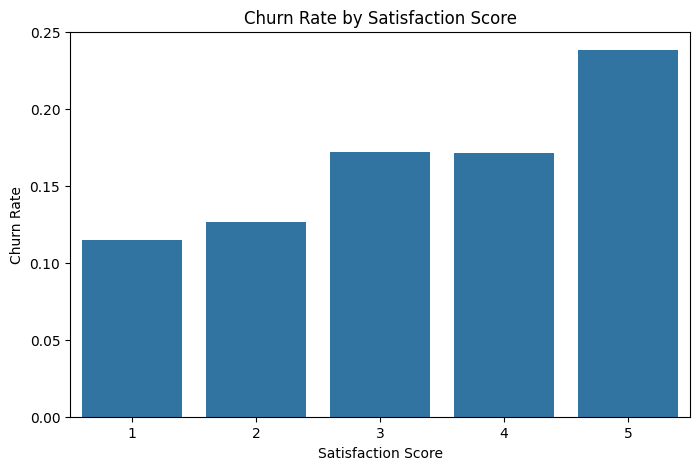

In [16]:
# SatisfactionScoreごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=satisfaction_churn, x='SatisfactionScore', y='churn_rate')
plt.title('Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Churn Rate')
plt.show()

- `SatisfactionScore` ごとの離脱率を確認したところ、スコアによって離脱率に差が見られた。
- 本データセットでは `SatisfactionScore` のスコアの向きが明記されていないため、値が高いほど満足度が高い、または低いとは断定しない。
- 一方で、`SatisfactionScore=5` の顧客では離脱率が高くなっており、離脱予測において有用な特徴量となる可能性がある。
- 後続のモデル構築では、`SatisfactionScore` を特徴量として使用し、モデル内での重要度を確認する。

### 2.3 クレーム有無と離脱率の関係

クレーム有無を表す `Complain` と離脱率の関係を確認する。

クレームがある顧客は、サービス体験に不満を持っている可能性があり、離脱リスクが高いと考えられる。

In [17]:
# Complainごとの離脱率と件数を集計
complain_churn = df.groupby('Complain').agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

complain_churn

,Complain,churn_rate,count
0,0,0.109290,4026
1,1,0.316708,1604


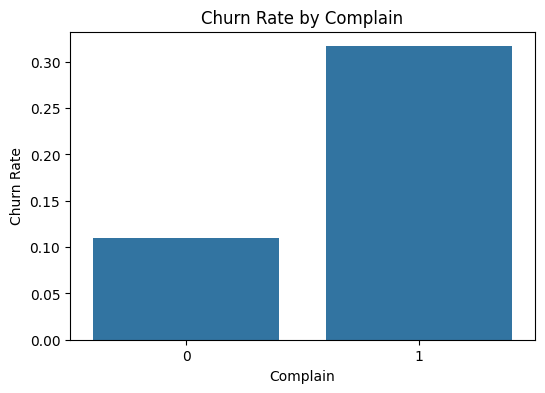

In [18]:
# Complainごとの離脱率を可視化
plt.figure(figsize=(6, 4))
sns.barplot(data=complain_churn, x='Complain', y='churn_rate')
plt.title('Churn Rate by Complain')
plt.xlabel('Complain')
plt.ylabel('Churn Rate')
plt.show()

- `Complain` ごとの離脱率を確認したところ、クレームなしの顧客の離脱率は約10.9%、クレームありの顧客の離脱率は約31.7%と、クレームありの顧客はクレームなしの顧客よりも離脱率が高い傾向が見られた。
- このことから、クレーム有無は離脱と強く関係している可能性がある。
- 実務上は、クレーム発生後のフォローやサポート対応の改善が、離脱防止施策として重要になると考えられる。
- 後続のモデル構築では、`Complain` を特徴量として使用し、モデル内での重要度を確認する。

### 2.4 注文回数と離脱率の関係

顧客の購買頻度を表す `OrderCount` と離脱率の関係を確認する。

一般的には、注文回数が少ない顧客ほどサービス利用が定着しておらず、離脱しやすい可能性がある。  
ここでは、注文回数を区間に分け、各区間ごとの離脱率を確認する。

In [19]:
# OrderCountを区間に分ける
df['OrderCount_bin'] = pd.cut(
    df['OrderCount'],
    bins=[0, 1, 3, 5, 10, np.inf],
    labels=['1', '2-3', '4-5', '6-10', '11+'],
    include_lowest=True
)

# OrderCount区間ごとの離脱率と件数を集計
order_count_bin_churn = df.groupby('OrderCount_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

order_count_bin_churn

,OrderCount_bin,churn_rate,count
0,1,0.180468,1751
1,2-3,0.182805,2396
2,4-5,0.109091,385
3,6-10,0.172920,613
4,11+,0.123348,227


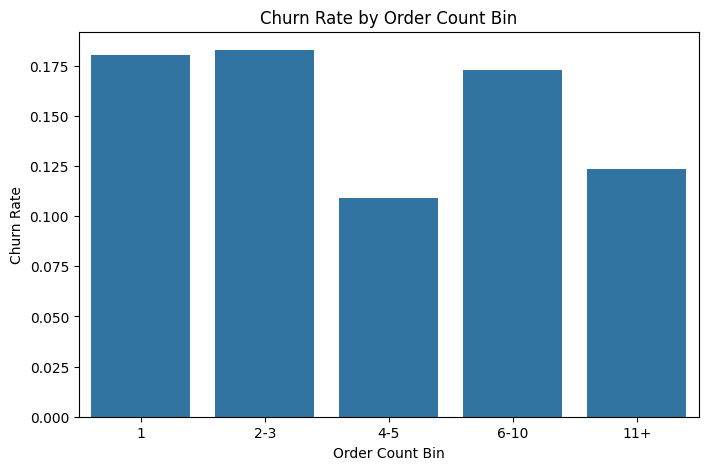

In [20]:
# OrderCount区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=order_count_bin_churn, x='OrderCount_bin', y='churn_rate')
plt.title('Churn Rate by Order Count Bin')
plt.xlabel('Order Count Bin')
plt.ylabel('Churn Rate')
plt.show()

- `OrderCount` を区間ごとに分けて離脱率を確認した。
- 注文回数が少ない顧客ほど離脱率が高い、という単純な傾向は見られなかった。
- 一方で、注文回数の区間ごとに離脱率には一定の差が見られる。
- 特に `1` や `2-3` の低頻度注文層では、離脱率が約18%前後となっている。
- ただし、注文回数が多い区間でも離脱率が高い箇所があり、`OrderCount` 単独で離脱傾向を説明するのは難しい。
- このことから、`OrderCount` は他の特徴量と組み合わせて利用することで有用になる可能性がある。
- 後続のモデル構築では、`OrderCount` を特徴量として使用し、モデル内での重要度を確認する。

### 2.5 最終注文からの日数と離脱率の関係

最終注文からの日数を表す `DaySinceLastOrder` と離脱率の関係を確認する。

一般的には、最終注文から日数が経過している顧客ほどサービス利用頻度が低下しており、離脱リスクが高い可能性がある。  
ここでは、最終注文からの日数を区間に分け、各区間ごとの離脱率を確認する。

In [21]:
# DaySinceLastOrderを区間に分ける
df['DaySinceLastOrder_bin'] = pd.cut(
    df['DaySinceLastOrder'],
    bins=[0, 3, 7, 14, np.inf],
    labels=['0-3', '4-7', '8-14', '15+'],
    include_lowest=True
)

# DaySinceLastOrder区間ごとの離脱率と件数を集計
last_order_churn = df.groupby('DaySinceLastOrder_bin', observed=False).agg(
    churn_rate=('Churn', 'mean'),
    count=('Churn', 'count')
).reset_index()

last_order_churn

,DaySinceLastOrder_bin,churn_rate,count
0,0-3,0.215560,2802
1,4-7,0.136998,1219
2,8-14,0.095161,1240
3,15+,0.080645,62


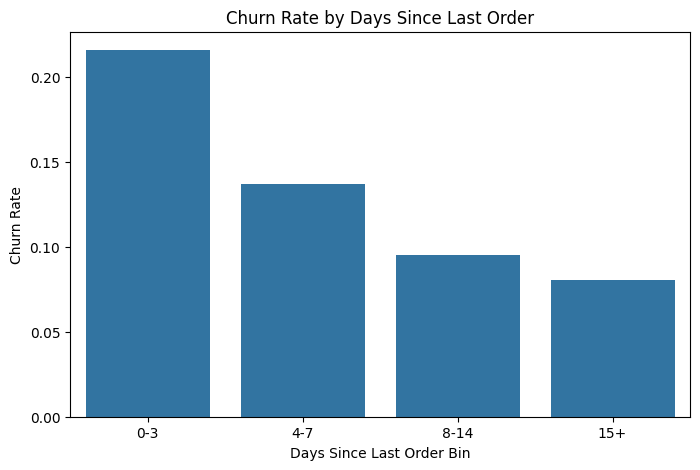

In [22]:
# DaySinceLastOrder区間ごとの離脱率を可視化
plt.figure(figsize=(8, 5))
sns.barplot(data=last_order_churn, x='DaySinceLastOrder_bin', y='churn_rate')
plt.title('Churn Rate by Days Since Last Order')
plt.xlabel('Days Since Last Order Bin')
plt.ylabel('Churn Rate')
plt.show()

- `DaySinceLastOrder` を区間ごとに分けて離脱率を確認した。
- 一般的には、最終注文から日数が経過している顧客ほど離脱リスクが高いと考えられる。
- しかし、本データでは `0-3` の区間で離脱率が最も高く、日数が長いほど離脱率が高くなるという単純な傾向は見られなかった。
- この結果は直感とは異なるが、本データセットでは `Churn` の具体的な定義や離脱判定のタイミングが明記されていないため、`DaySinceLastOrder` を単純な休眠期間として解釈するのは難しい。
- この結果から、`DaySinceLastOrder` は単独で離脱を説明するというより、`Tenure` や `Complain`、`OrderCount` など他の特徴量と組み合わせて解釈する必要がある。
- 後続のモデル構築では、`DaySinceLastOrder` を特徴量として使用し、モデル内での重要度を確認する。

### 2.6 カテゴリ変数ごとの離脱率

カテゴリ変数ごとに離脱率を確認する。

ログイン端末、支払い方法、性別、主な注文カテゴリ、婚姻状況などのカテゴリによって、離脱率に違いがあるかを確認する。

,PreferredLoginDevice,churn_rate,count
0,Phone,0.224208,1231
1,Computer,0.198286,1634
2,Mobile Phone,0.125859,2765


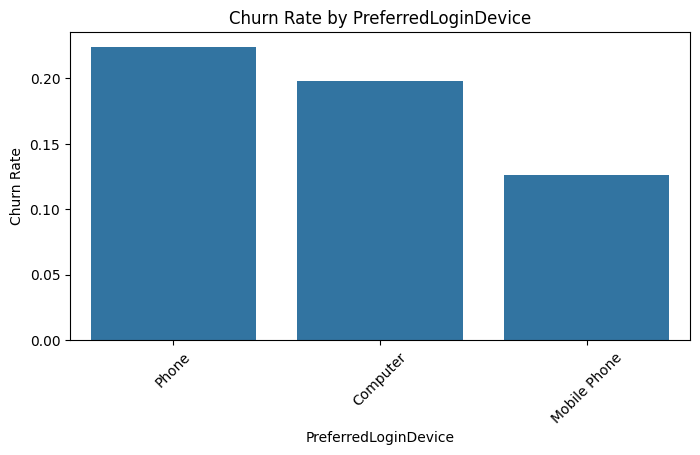

,PreferredPaymentMode,churn_rate,count
0,COD,0.287671,365
1,E wallet,0.228013,614
2,CC,0.216117,273
3,UPI,0.173913,414
4,Cash on Delivery,0.154362,149
5,Debit Card,0.153846,2314
6,Credit Card,0.128581,1501


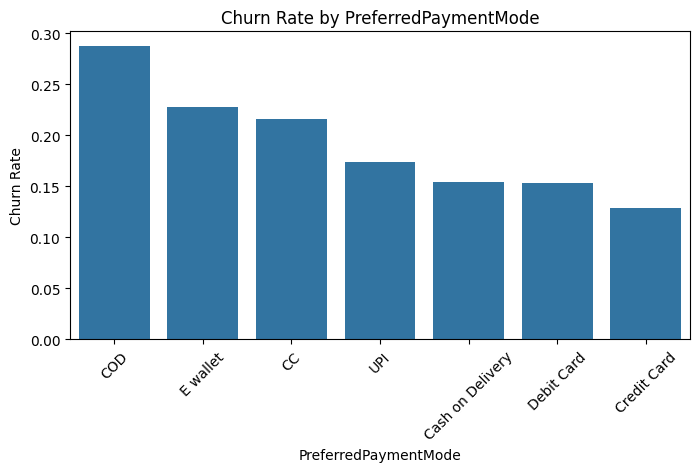

,Gender,churn_rate,count
0,Male,0.177305,3384
1,Female,0.154942,2246


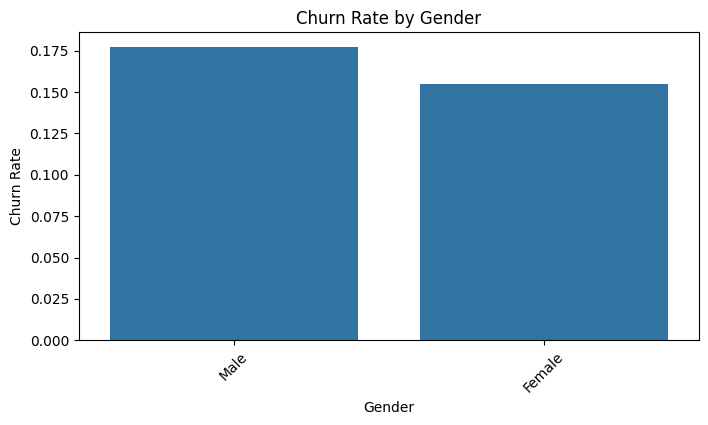

,PreferedOrderCat,churn_rate,count
0,Mobile Phone,0.275374,1271
1,Mobile,0.271941,809
2,Fashion,0.154964,826
3,Laptop & Accessory,0.102439,2050
4,Others,0.075758,264
5,Grocery,0.048780,410


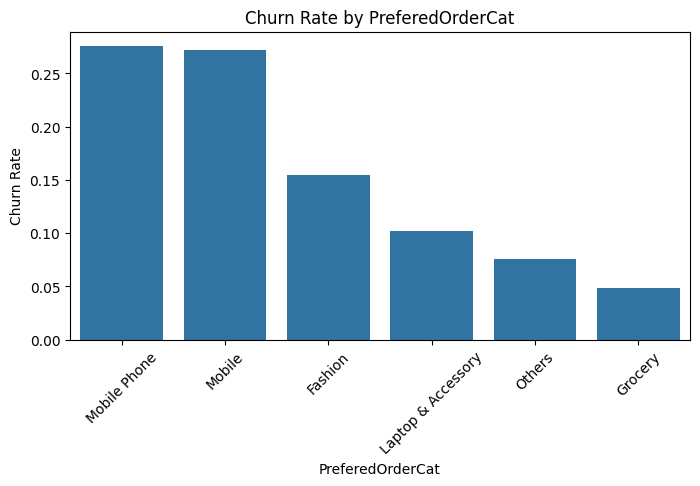

,MaritalStatus,churn_rate,count
0,Single,0.267261,1796
1,Divorced,0.146226,848
2,Married,0.115204,2986


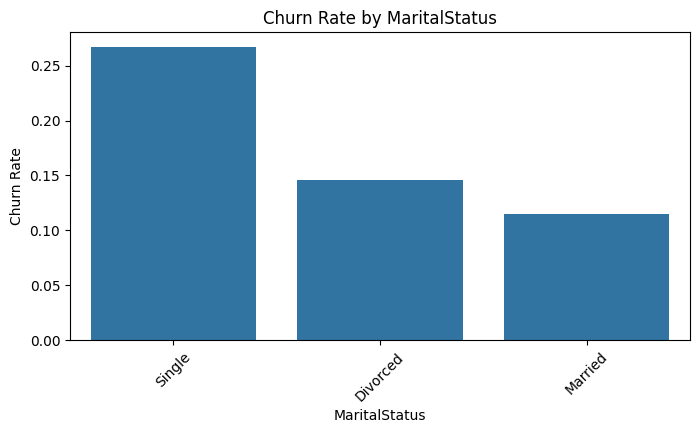

In [23]:
# カテゴリ変数ごとの離脱率と件数を確認
for col in cat_cols:
    churn_by_cat = df.groupby(col).agg(
        churn_rate=('Churn', 'mean'),
        count=('Churn', 'count')
    ).sort_values('churn_rate', ascending=False).reset_index()

    display(churn_by_cat)

    plt.figure(figsize=(8, 4))
    sns.barplot(data=churn_by_cat, x=col, y='churn_rate')
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45)
    plt.show()

- カテゴリ変数ごとの離脱率を確認したところ、複数のカテゴリで離脱率に差が見られた。
- `PreferredLoginDevice` では、`Phone` や `Computer` の離脱率が相対的に高く、`Mobile Phone` は低い傾向が見られた。
- `PreferredPaymentMode` では、`COD`、`E wallet`、`CC` の離脱率が相対的に高く、支払い方法によって離脱傾向に差がある可能性がある。
- `Gender` では、男性の離脱率が女性よりやや高いが、差は大きくないため、単独で強く解釈するのは避ける。
- `PreferedOrderCat` では、`Mobile Phone` や `Mobile` の離脱率が高く、商品カテゴリによって離脱傾向に違いが見られた。
- `MaritalStatus` では、`Single` の離脱率が最も高く、`Married` の離脱率が低い傾向が見られた。
- ただし、カテゴリごとに件数が異なるため、離脱率だけでなく母数も確認しながら解釈する必要がある。
- また、`PreferredPaymentMode` の `CC` と `Credit Card`、`COD` と `Cash on Delivery` など、意味が近い可能性のあるカテゴリも存在するため、実務ではデータ定義を確認したうえで表記ゆれの統一を検討する。
- 後続の前処理では、これらのカテゴリ変数をOne-Hot Encodingし、モデルに利用する。

### 2.7 数値変数同士の相関

数値変数同士の相関を確認する。

相関を確認することで、目的変数である `Churn` と関係がありそうな変数や、説明変数同士で強く関連している変数を把握する。


In [24]:
# CustomerIDは識別用IDのため、相関分析から除外
corr_cols = [col for col in num_cols if col != 'CustomerID']

# 数値変数同士の相関を計算
corr = df[corr_cols].corr()

corr

,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Churn,1.000000,-0.349408,0.084703,0.076630,0.018675,0.107939,0.105481,0.043931,0.250188,-0.010058,-0.008264,-0.028697,-0.160757,-0.154118
Tenure,-0.349408,1.000000,-0.060688,-0.018218,-0.021226,-0.023983,-0.013903,0.237666,-0.021268,0.005825,0.129035,0.186403,0.184552,0.476380
CityTier,0.084703,-0.060688,1.000000,0.010624,-0.009150,0.027934,-0.011554,-0.029440,0.003375,-0.031408,0.021456,0.033388,0.017525,0.055746
WarehouseToHome,0.076630,-0.018218,0.010624,1.000000,0.060990,0.019071,0.007722,-0.011020,0.028696,0.038795,-0.003935,0.002681,0.017829,-0.009200
HourSpendOnApp,0.018675,-0.021226,-0.009150,0.060990,1.000000,0.316800,0.031858,0.145126,0.006976,0.106843,0.191528,0.109575,0.075716,0.121490
NumberOfDeviceRegistered,0.107939,-0.023983,0.027934,0.019071,0.316800,1.000000,-0.017228,0.084997,0.003407,0.069475,0.151685,0.103464,0.018208,0.137183
SatisfactionScore,0.105481,-0.013903,-0.011554,0.007722,0.031858,-0.017228,1.000000,0.053583,-0.031115,-0.027730,0.017936,0.019764,0.032082,0.003473
NumberOfAddress,0.043931,0.237666,-0.029440,-0.011020,0.145126,0.084997,0.053583,1.000000,-0.026399,0.015533,0.042120,-0.007609,-0.064847,0.186688
Complain,0.250188,-0.021268,0.003375,0.028696,0.006976,0.003407,-0.031115,-0.026399,1.000000,-0.004529,-0.008174,-0.019307,-0.043546,0.000525
OrderAmountHikeFromlastYear,-0.010058,0.005825,-0.031408,0.038795,0.106843,0.069475,-0.027730,0.015533,-0.004529,1.000000,0.033201,0.023101,0.006003,0.017869


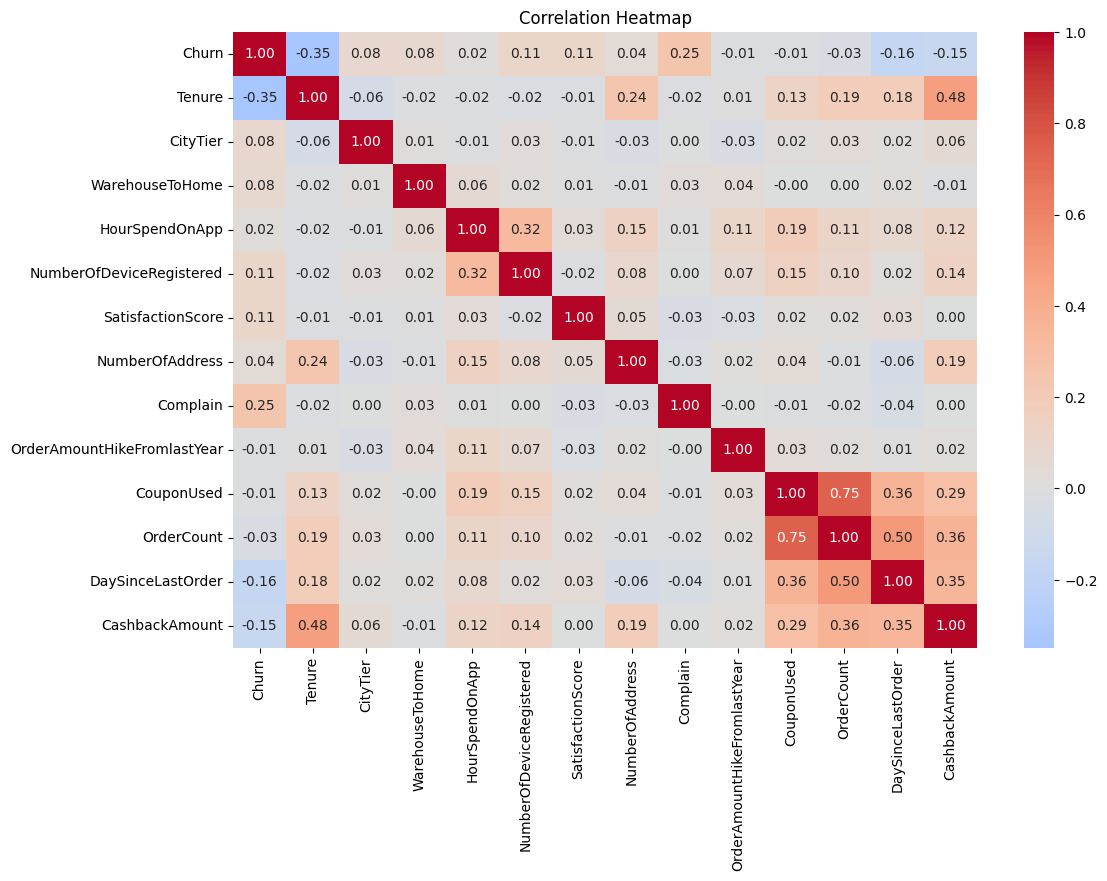

In [25]:
# 相関係数をヒートマップで可視化
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

### 2.8 EDAまとめ

本章では、顧客属性・利用状況・購買行動と離脱率の関係を確認した。

主な結果は以下の通りである。

- `Tenure` を確認したところ、利用開始初期の顧客ほど離脱率が高い傾向が見られた。
- `SatisfactionScore` はスコアの向きが明記されていないものの、スコアによって離脱率に差が見られた。
- `Complain` では、クレームありの顧客はクレームなしの顧客と比較して離脱率が高い傾向が見られた。
- `OrderCount` や `DaySinceLastOrder` は、単独で離脱を説明するというより、他の特徴量と組み合わせて解釈する必要がある。
- カテゴリ変数ごとの離脱率にも差が見られ、顧客属性や利用状況によって離脱傾向が異なる可能性がある。
- 相関分析では、`Tenure` や `Complain` などが `Churn` と一定の関係を持つ可能性が示された。
- 後続のモデル構築では、`CustomerID` と目的変数である `Churn`、およびEDA用に作成した派生列を除いた特徴量を使用する。
- 相関が弱い特徴量であっても、非線形な関係や他の特徴量との組み合わせによって予測に寄与する可能性があるため、最終的な有用性はFeature ImportanceやSHAPで確認する。

## 3. 前処理と特徴量整理

ここからは、モデル構築に向けて前処理を行う。

本分析では、目的変数である `Churn` を予測対象とし、顧客属性・利用状況・購買行動に関する特徴量を用いて分類モデルを構築する。

後続のモデリングでは、解釈しやすい線形モデルである `Logistic Regression` と、表形式データに強い木系モデルである `LightGBM` を比較する。  
そのため、本章ではそれぞれのモデルで利用できるように前処理の流れを定義する。
前処理では、以下を実施する。

- 目的変数と説明変数の分割
- モデリングに使用しない列の除外
- 学習データとテストデータの分割
- 数値変数の欠損値補完・標準化
- カテゴリ変数の欠損値補完・エンコーディング

前述の通り、EDAで作成した `Tenure_bin`、`OrderCount_bin`、`DaySinceLastOrder_bin` は可視化用の派生列であり、元の特徴量と情報が重複するため、モデリングでは使用しない。

### 3.1 目的変数・説明変数の分割と学習データの作成

モデリングに向けて、目的変数 `Churn` と説明変数を分割する。

本分析では、まずデータを学習データとテストデータに分割し、テストデータは最終評価用として保持する。  
モデル比較やハイパーパラメータ調整を行う場合は、学習データ内で交差検証を行い、テストデータは最後の性能確認にのみ使用する。

欠損値補完やエンコーディングは、テストデータの情報が学習時に混入しないよう、学習データに対してのみルールを学習し、そのルールをテストデータに適用する。

なお、`Churn` はクラス不均衡を含むため、学習データとテストデータで離脱率の比率が大きく変わらないよう、層化抽出を行う。

In [26]:
from sklearn.model_selection import train_test_split

# 目的変数
target = 'Churn'

# モデリングで使用しない列
drop_cols = [
    'CustomerID',
    'Tenure_bin',
    'OrderCount_bin',
    'DaySinceLastOrder_bin'
]

# 説明変数と目的変数に分割
X = df.drop(columns=[target] + drop_cols)
y = df[target]

# 学習データ・テストデータへ8:2の割合で分割
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (4504, 18)
X_test : (1126, 18)
y_train: (4504,)
y_test : (1126,)


In [27]:
# 学習データ・テストデータの離脱率を確認
print(f'全体の離脱率　　　: {y.mean():.2%}')
print(f'学習データの離脱率: {y_train.mean():.2%}')
print(f'テストデータの離脱率: {y_test.mean():.2%}')

全体の離脱率　　　: 16.84%
学習データの離脱率: 16.83%
テストデータの離脱率: 16.87%


- 目的変数 `Churn` と説明変数を分割した。
- `CustomerID` は顧客識別用のIDであり、予測には直接使用しないため除外した。
- EDAで作成した `Tenure_bin`、`OrderCount_bin`、`DaySinceLastOrder_bin` は可視化用の派生列であり、元の特徴量と情報が重複するため除外した。
- データは学習データ80%、テストデータ20%に分割した。
- `stratify=y` を指定したことで、学習データとテストデータの離脱率はそれぞれ約16.8%となり、全体の離脱率と近い比率を保ったまま分割できている。

### 3.2 数値変数・カテゴリ変数の整理

前処理Pipelineを作成するため、説明変数を数値変数とカテゴリ変数に分ける。

まずは、`X_train` のデータ型をもとに数値変数とカテゴリ変数を抽出する。  
そのうえで、`SatisfactionScore` や `CityTier` は数値型として読み込まれているものの、連続量というより評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面があるため、本分析ではカテゴリ変数として扱う。

一方で、`Complain` は0/1で表現された二値フラグであるため、数値変数としてそのまま扱う。

In [28]:
# データ型をもとに数値変数・カテゴリ変数を抽出
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print('データ型ベースの数値変数')
print(num_cols)

print('\nデータ型ベースのカテゴリ変数')
print(cat_cols)

データ型ベースの数値変数
['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

データ型ベースのカテゴリ変数
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [29]:
# 数値型として読み込まれているが、カテゴリ変数として扱うカラム
categorical_like_cols = ['SatisfactionScore', 'CityTier']

# モデリング用の数値変数
num_cols_model = [col for col in num_cols if col not in categorical_like_cols]

# モデリング用のカテゴリ変数
cat_cols_model = cat_cols + categorical_like_cols

print('モデリング用 数値変数')
print(num_cols_model)

print('\nモデリング用 カテゴリ変数')
print(cat_cols_model)

print(f'\nモデリング用 数値変数の数: {len(num_cols_model)}')
print(f'モデリング用 カテゴリ変数の数: {len(cat_cols_model)}')

モデリング用 数値変数
['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

モデリング用 カテゴリ変数
['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus', 'SatisfactionScore', 'CityTier']

モデリング用 数値変数の数: 11
モデリング用 カテゴリ変数の数: 7


- `X_train` を基準に、数値変数とカテゴリ変数を整理した。
- データ型ベースでは、数値変数が13個、カテゴリ変数が5個であることを確認した。
- `SatisfactionScore` や `CityTier` は数値型として読み込まれているが、連続量というより評価スコアや都市階層を表す変数であり、カテゴリ変数に近い側面がある。
- そのため、本分析では `SatisfactionScore` と `CityTier` をカテゴリ変数として扱い、One-Hot Encodingを行う。
- `Complain` は0/1で表現された二値フラグであるため、数値変数としてそのまま扱う。

### 3.3 前処理の定義

ここでは、`Logistic Regression` 用と `LightGBM` 用に、それぞれ前処理を定義する。

`Logistic Regression` は特徴量のスケールの影響を受けやすいため、数値変数には中央値補完に加えて標準化を行う。  
一方で、`LightGBM` は木系モデルであり特徴量のスケールの影響を受けにくいため、数値変数には中央値補完のみを行う。

カテゴリ変数には、両モデルとも最頻値補完とOne-Hot Encodingを行う。

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Logistic Regression用：数値変数は中央値補完 + 標準化
numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# LightGBM用：数値変数は中央値補完のみ
numeric_transformer_lgbm = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# カテゴリ変数：最頻値補完 + One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Logistic Regression用の前処理
preprocessor_lr = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lr, num_cols_model),
        ('cat', categorical_transformer, cat_cols_model)
    ]
)

# LightGBM用の前処理
preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_lgbm, num_cols_model),
        ('cat', categorical_transformer, cat_cols_model)
    ]
)

- `Logistic Regression` 用と `LightGBM` 用に、それぞれ前処理を定義した。
- `OneHotEncoder(handle_unknown='ignore')` を指定することで、テストデータに学習データには存在しないカテゴリが含まれていてもエラーにならないようにした。
- 後続のモデリングでは、これらの前処理と分類モデルを組み合わせて学習・評価を行う。

## 4. モデリング

ここからは、前処理と分類モデルを組み合わせて、顧客の離脱有無を予測するモデルを構築する。

本分析では、以下のモデルを比較する。

- ベースラインモデル
- Logistic Regression
- LightGBM

本データは離脱顧客が少ないクラス不均衡データであるため、Accuracyだけでなく、離脱顧客をどの程度検出できているかを表すRecallや、離脱と予測した顧客のうち実際に離脱している割合を表すPrecisionも確認する。

また、閾値に依存しない形でPrecisionとRecallのバランスを確認するため、PR-AUCも確認する。  
本分析では、PR-AUCに相当する指標として、scikit-learnの `average_precision_score` を用いる。

なお、F1-scoreは特定の閾値におけるPrecisionとRecallのバランスを表す指標であるため、後続の閾値調整で確認する。

### 4.1 ベースラインモデル

まずは、すべての顧客を多数派クラスである `Churn=0` と予測するベースラインモデルを作成する。

本データでは継続顧客が多数を占めているため、単純に多数派クラスを予測するだけでもAccuracyは一定程度高くなる可能性がある。  
このベースラインと比較することで、後続の機械学習モデルが少数派である離脱顧客をどの程度検出できるかを確認する。

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    average_precision_score,
    confusion_matrix
)

# すべての顧客を継続顧客（Churn=0）と予測
baseline_pred = np.zeros_like(y_test)

# PR-AUC計算用に、全員の離脱確率を0とする
baseline_proba = np.zeros_like(y_test, dtype=float)

# 評価指標を計算
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, zero_division=0)
baseline_recall = recall_score(y_test, baseline_pred)
baseline_pr_auc = average_precision_score(y_test, baseline_proba)

print(f'Accuracy : {baseline_accuracy:.4f}')
print(f'Precision: {baseline_precision:.4f}')
print(f'Recall   : {baseline_recall:.4f}')
print(f'PR-AUC   : {baseline_pr_auc:.4f}')

Accuracy : 0.8313
Precision: 0.0000
Recall   : 0.0000
PR-AUC   : 0.1687


In [32]:
# 混同行列を確認
baseline_cm = confusion_matrix(y_test, baseline_pred)
baseline_cm_df = pd.DataFrame(
    baseline_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

baseline_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,936,0
Actual Churn=1,190,0


In [33]:
# ベースラインモデルの評価結果を保存
baseline_result = pd.DataFrame({
    'model': ['Baseline'],
    'accuracy': [baseline_accuracy],
    'precision': [baseline_precision],
    'recall': [baseline_recall],
    'pr_auc': [baseline_pr_auc]
})

baseline_result

,model,accuracy,precision,recall,pr_auc
0,Baseline,0.831261,0.0,0.0,0.168739


- ベースラインモデルとして、すべての顧客を多数派クラスである `Churn=0` と予測した。
- Accuracyは約83.1%となったが、これは継続顧客が多数を占めるクラス不均衡の影響によるものである。
- 混同行列を見ると、実際の離脱顧客190人はすべて `Churn=0` と予測されており、離脱顧客を一人も検出できていない。
- そのため、Recallは0となった。
- また、`Churn=1` と予測された顧客が存在しないため、Precisionは数学的には未定義となるが、本分析では `zero_division=0` を指定し、0として扱った。
- PR-AUCは約0.169となり、テストデータの離脱率とほぼ同水準であった。
- 以上より、Accuracyは高く見えても、離脱顧客を検出できているとは限らないことが分かる。
- 後続のモデル評価では、Accuracyだけでなく、Recall、Precision、PR-AUCもあわせて確認する。

### 4.2 Logistic Regression

次に、解釈しやすい線形モデルである `Logistic Regression` を構築する。

`Logistic Regression` は、特徴量と目的変数の関係を係数として確認できるため、比較的解釈しやすいモデルである。

本データでは離脱顧客が少ないため、通常の学習では多数派である継続顧客に予測が偏る可能性がある。  
そのため、`class_weight='balanced'` を指定し、少数派である離脱顧客の誤分類を相対的に重く扱うことで、離脱顧客を検出しやすくする。

In [34]:
from sklearn.linear_model import LogisticRegression

# Logistic Regressionモデルを定義
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# 前処理とモデルをPipeline化
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', lr_model)
])

# 学習
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus',
                                                   'SatisfactionScore',
                                                   'CityTier'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [35]:
# 予測ラベルと予測確率を取得
lr_pred = lr_pipeline.predict(X_test)
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]

# 評価指標を計算
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, zero_division=0)
lr_recall = recall_score(y_test, lr_pred)
lr_pr_auc = average_precision_score(y_test, lr_proba)

print(f'Accuracy : {lr_accuracy:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'Recall   : {lr_recall:.4f}')
print(f'PR-AUC   : {lr_pr_auc:.4f}')

Accuracy : 0.7895
Precision: 0.4363
Recall   : 0.8474
PR-AUC   : 0.6799


In [36]:
# 混同行列を確認
lr_cm = confusion_matrix(y_test, lr_pred)

lr_cm_df = pd.DataFrame(
    lr_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

lr_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,728,208
Actual Churn=1,29,161


In [37]:
# Logistic Regressionの評価結果を保存
lr_result = pd.DataFrame({
    'model': ['Logistic Regression'],
    'accuracy': [lr_accuracy],
    'precision': [lr_precision],
    'recall': [lr_recall],
    'pr_auc': [lr_pr_auc]
})

lr_result

,model,accuracy,precision,recall,pr_auc
0,Logistic Regression,0.78952,0.436314,0.847368,0.679937


- `Logistic Regression` を用いて離脱予測モデルを構築した。
- Accuracyは約78.9%となり、ベースラインモデルの約83.1%より低下した。
- 一方で、Recallは約84.7%となり、実際の離脱顧客190人のうち161人を検出できた。
- Precisionは約43.6%であり、離脱と予測した顧客には一定数の継続顧客も含まれている。
- PR-AUCは約0.680となり、ベースラインモデルの約0.169を大きく上回った。
- この結果から、`Logistic Regression` はベースラインモデルと比較して、離脱顧客の検出性能が改善していると考えられる。

### 4.3 LightGBM

次に、表形式データに強い木系モデルである `LightGBM` を構築する。

`LightGBM` は、非線形な関係や特徴量同士の相互作用を捉えやすく、表形式データでよく用いられるモデルである。

ここでは、3章で作成した `LightGBM` 用の前処理とモデルをPipelineで結合し、学習データでモデルを学習する。

In [38]:
from lightgbm import LGBMClassifier

# LightGBMモデルを定義
lgbm_model = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

# 前処理とモデルをPipeline化
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('model', lgbm_model)
])

# 学習
lgbm_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Tenure', 'WarehouseToHome',
                                                   'HourSpendOnApp',
                                                   'NumberOfDeviceRegistered',
                                                   'NumberOfAddress',
                                                   'Complain',
                                                   'OrderAmountHikeFromlastYear',
                                                   'CouponUsed', 'OrderCount',
                                                   'DaySinceLastOrder',
                                                   'CashbackAmount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['PreferredLoginDevice',
                                                   'PreferredPaymentMode',
                                                   'Gender', 'PreferedOrderCat',
                                                   'MaritalStatus',
                                                   'SatisfactionScore',
                                                   'CityTier'])])),
                ('model',
                 LGBMClassifier(class_weight='balanced', random_state=42,
                                verbose=-1))])

In [39]:
# 予測ラベルと予測確率を取得
lgbm_pred = lgbm_pipeline.predict(X_test)
lgbm_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

# 評価指標を計算
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
lgbm_precision = precision_score(y_test, lgbm_pred, zero_division=0)
lgbm_recall = recall_score(y_test, lgbm_pred)
lgbm_pr_auc = average_precision_score(y_test, lgbm_proba)

print(f'Accuracy : {lgbm_accuracy:.4f}')
print(f'Precision: {lgbm_precision:.4f}')
print(f'Recall   : {lgbm_recall:.4f}')
print(f'PR-AUC   : {lgbm_pr_auc:.4f}')

Accuracy : 0.9645
Precision: 0.8348
Recall   : 0.9842
PR-AUC   : 0.9857


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [40]:
# 混同行列を確認
lgbm_cm = confusion_matrix(y_test, lgbm_pred)

lgbm_cm_df = pd.DataFrame(
    lgbm_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

lgbm_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,899,37
Actual Churn=1,3,187


In [41]:
# LightGBMの評価結果を保存
lgbm_result = pd.DataFrame({
    'model': ['LightGBM'],
    'accuracy': [lgbm_accuracy],
    'precision': [lgbm_precision],
    'recall': [lgbm_recall],
    'pr_auc': [lgbm_pr_auc]
})

lgbm_result

,model,accuracy,precision,recall,pr_auc
0,LightGBM,0.964476,0.834821,0.984211,0.985688


In [42]:
# モデルに使用している特徴量を確認
print(X.columns.tolist())

# 目的変数・ID・EDA用派生列が説明変数に含まれていないことを確認
leak_cols = {'Churn', 'CustomerID', 'Tenure_bin', 'OrderCount_bin', 'DaySinceLastOrder_bin'}

leak_cols & set(X.columns)

['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


set()

- `LightGBM` を用いて離脱予測モデルを構築した。
- Accuracyは約96.4%、Precisionは約83.5%、Recallは約98.4%、PR-AUCは約0.986となり、いずれの指標も高い水準となった。
- 混同行列を見ると、実際の離脱顧客190人のうち187人を検出できており、離脱顧客の見逃しは3人に抑えられている。
- `Logistic Regression` と比較しても、Accuracy、Precision、Recall、PR-AUCのすべてで上回っており、本データでは `LightGBM` がより高い予測性能を示した。
- 一方で、性能が非常に高いため、目的変数・ID・EDA用派生列の混入がないかを確認したところ、コード上の明確なデータリークは確認されなかった。
- ただし、本データセットでは `Churn` の具体的な定義や各特徴量の取得時点が明記されていないため、実務では予測時点で利用可能な特徴量かどうかを確認する必要がある。

### 4.4 モデル比較

ここでは、ベースラインモデル、`Logistic Regression`、`LightGBM` の評価結果を比較する。

In [43]:
# 各モデルの評価結果を結合
model_results = pd.concat(
    [baseline_result, lr_result, lgbm_result],
    ignore_index=True
)
# 評価結果を小数第3位で表示
model_results.round(3)

,model,accuracy,precision,recall,pr_auc
0,Baseline,0.831,0.000,0.000,0.169
1,Logistic Regression,0.790,0.436,0.847,0.680
2,LightGBM,0.964,0.835,0.984,0.986


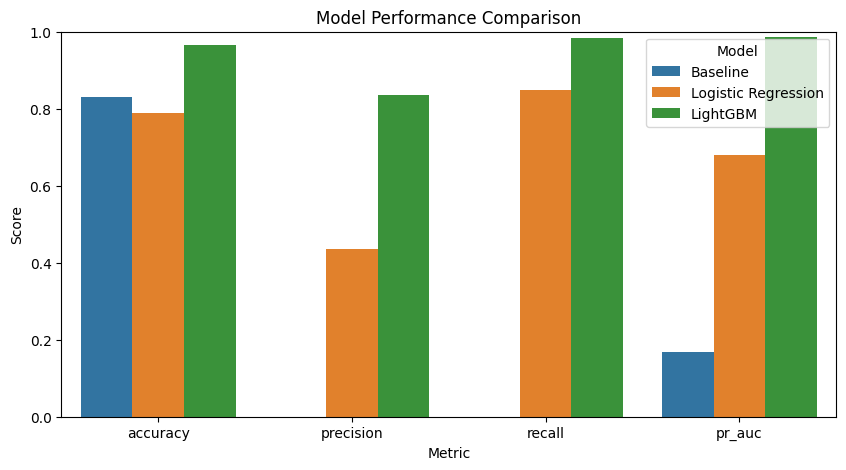

In [44]:
# モデルごとの評価指標を可視化
model_results_melted = model_results.melt(
    id_vars='model',
    value_vars=['accuracy', 'precision', 'recall', 'pr_auc'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=model_results_melted, x='metric', y='score', hue='model')
plt.title('Model Performance Comparison')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.show()

- 3モデルの評価結果を比較した。
- ベースラインモデルはAccuracyが約83.1%となったが、RecallとPrecisionは0であり、離脱顧客を検出できていない。
- `Logistic Regression` は、Accuracyは約79.0%とベースラインより低い一方で、Recallは約84.7%となり、離脱顧客を一定程度検出できている。
- `LightGBM` は、Accuracy、Precision、Recall、PR-AUCのすべてで最も高い値となった。
- 特にRecallは約98.4%、Precisionは約83.5%であり、離脱顧客の見逃しを抑えつつ、離脱予測の精度も高い結果となった。
- 以上より、本分析では `LightGBM` を最終モデルとして採用し、後続のハイパーパラメータ調整や閾値調整を行う。

## 5. ハイパーパラメータ調整

4章のモデル比較では、`LightGBM` が最も高い予測性能を示した。

ここでは、最終モデルとして採用する `LightGBM` について、ハイパーパラメータ調整を行う。  
学習データ内で交差検証を行い、PR-AUCを評価指標として、より性能の高いパラメータを探索する。

なお、テストデータは最終評価用として保持し、ハイパーパラメータ調整には使用しない。

### 5.1 LightGBMのハイパーパラメータ調整

`LightGBM` の主要なハイパーパラメータを調整する。

本分析では、探索範囲を広げすぎず、代表的なパラメータに絞って `RandomizedSearchCV` による探索を行う。  
評価指標には、クラス不均衡データにおける少数派クラスの検出性能を確認するため、PR-AUCに相当する `average_precision` を用いる。

In [45]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# LightGBMモデルを定義
lgbm_model_tuning = LGBMClassifier(
    random_state=42,
    class_weight='balanced',
    verbose=-1
)

# 前処理とモデルをPipeline化
lgbm_pipeline_tuning = Pipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('model', lgbm_model_tuning)
])

# 探索するハイパーパラメータ
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves': [15, 31, 63],
    'model__max_depth': [-1, 3, 5, 7],
    'model__min_child_samples': [10, 20, 30, 50],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# 交差検証の設定
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# RandomizedSearchCVで探索
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline_tuning,
    param_distributions=param_dist,
    n_iter=30,
    scoring='average_precision',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 学習データ内でハイパーパラメータ調整
lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Tenure',
                                                                                'WarehouseToHome',
                                                                                'HourSpendOnApp',
                                                                                'NumberOfDeviceRegistered',
                                                                                'NumberOfAddress',
                                                                                'Complain',
                                                                                'OrderAmountHikeFromlastYe...
                   n_iter=30, n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.7, 0.8,
                                                                    1.0],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [-1, 3, 5, 7],
                                        'model__min_child_samples': [10, 20, 30,
                                                                     50],
                                        'model__n_estimators': [100, 200, 300,
                                                                500],
                                        'model__num_leaves': [15, 31, 63],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='average_precision', verbose=1)

In [46]:
# 最良パラメータとCVスコアを確認
print('Best Parameters:')
print(lgbm_search.best_params_)

print(f"\nBest CV PR-AUC: {lgbm_search.best_score_:.4f}")

Best Parameters:
{'model__subsample': 0.7, 'model__num_leaves': 63, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}

Best CV PR-AUC: 0.9463


In [47]:
# 最良モデルを取得
best_lgbm_pipeline = lgbm_search.best_estimator_

# テストデータで予測
best_lgbm_pred = best_lgbm_pipeline.predict(X_test)
best_lgbm_proba = best_lgbm_pipeline.predict_proba(X_test)[:, 1]

# 評価指標を計算
best_lgbm_accuracy = accuracy_score(y_test, best_lgbm_pred)
best_lgbm_precision = precision_score(y_test, best_lgbm_pred, zero_division=0)
best_lgbm_recall = recall_score(y_test, best_lgbm_pred)
best_lgbm_pr_auc = average_precision_score(y_test, best_lgbm_proba)

print(f'Accuracy : {best_lgbm_accuracy:.4f}')
print(f'Precision: {best_lgbm_precision:.4f}')
print(f'Recall   : {best_lgbm_recall:.4f}')
print(f'PR-AUC   : {best_lgbm_pr_auc:.4f}')

Accuracy : 0.9947
Precision: 0.9842
Recall   : 0.9842
PR-AUC   : 0.9990


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [48]:
# 混同行列を確認
best_lgbm_cm = confusion_matrix(y_test, best_lgbm_pred)

best_lgbm_cm_df = pd.DataFrame(
    best_lgbm_cm,
    index=['Actual Churn=0', 'Actual Churn=1'],
    columns=['Predicted Churn=0', 'Predicted Churn=1']
)

best_lgbm_cm_df

,Predicted Churn=0,Predicted Churn=1
Actual Churn=0,933,3
Actual Churn=1,3,187


In [49]:
# チューニング後LightGBMの評価結果を保存
best_lgbm_result = pd.DataFrame({
    'model': ['LightGBM Tuned'],
    'accuracy': [best_lgbm_accuracy],
    'precision': [best_lgbm_precision],
    'recall': [best_lgbm_recall],
    'pr_auc': [best_lgbm_pr_auc]
})

best_lgbm_result

,model,accuracy,precision,recall,pr_auc
0,LightGBM Tuned,0.994671,0.984211,0.984211,0.999014


### 5.2 チューニング前後の性能比較

ここでは、チューニング前後の `LightGBM` の評価結果を比較する。

In [50]:
# チューニング前後のLightGBMの評価結果を比較
tuning_comparison = pd.concat(
    [lgbm_result, best_lgbm_result],
    ignore_index=True
)

tuning_comparison.round(3)

,model,accuracy,precision,recall,pr_auc
0,LightGBM,0.964,0.835,0.984,0.986
1,LightGBM Tuned,0.995,0.984,0.984,0.999


- チューニング前後の `LightGBM` の性能を比較したところ、 チューニング後はAccuracyが約99.5%、Precisionが約98.4%、Recallが約98.4%、PR-AUCが約0.999となった。
- Recallはチューニング前と同水準を維持しつつ、Precisionが約83.5%から約98.4%へ大きく改善した。
- 混同行列を見ると、離脱顧客の見逃しは3人のまま維持され、継続顧客を誤って離脱と予測した件数は37人から3人に減少した。
- この結果から、ハイパーパラメータ調整により、離脱顧客の検出力を維持しながら誤検出を大きく抑えられたと考えられる。

## 6. 閾値調整

ここでは、チューニング後の `LightGBM` を対象に、予測確率の閾値を調整する。

これまでの評価では、デフォルトの閾値0.5を用いて `Churn=0/1` を判定した。  
一方、実務における離脱予測では、離脱顧客の見逃しを減らしたいのか、施策対象を絞りたいのかによって適切な閾値は変わる。

そのため、複数の閾値におけるPrecision、Recall、F1-score、施策対象人数を確認し、目的に応じた閾値を検討する。

### 6.1 閾値ごとの評価指標の確認

チューニング後LightGBMの予測確率を用いて、閾値を変化させた場合の評価指標を確認する。

閾値を下げると離脱と判定する顧客が増えるため、Recallは上がりやすくなる一方で、Precisionは下がりやすくなる。  
反対に、閾値を上げると施策対象は絞られるが、離脱顧客を見逃す可能性が高くなる。

In [53]:
from sklearn.metrics import f1_score

# 閾値ごとの評価指標を確認
thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (best_lgbm_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    target_count = y_pred_threshold.sum()
    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'target_count': target_count
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.round(3)

,threshold,accuracy,precision,recall,f1_score,target_count
0,0.1,0.993,0.969,0.989,0.979,194
1,0.2,0.992,0.969,0.984,0.977,193
2,0.3,0.993,0.974,0.984,0.979,192
3,0.4,0.995,0.984,0.984,0.984,190
4,0.5,0.995,0.984,0.984,0.984,190
5,0.6,0.994,0.984,0.979,0.982,189
6,0.7,0.993,0.984,0.974,0.979,188
7,0.8,0.991,0.984,0.963,0.973,186
8,0.9,0.992,1.000,0.953,0.976,181


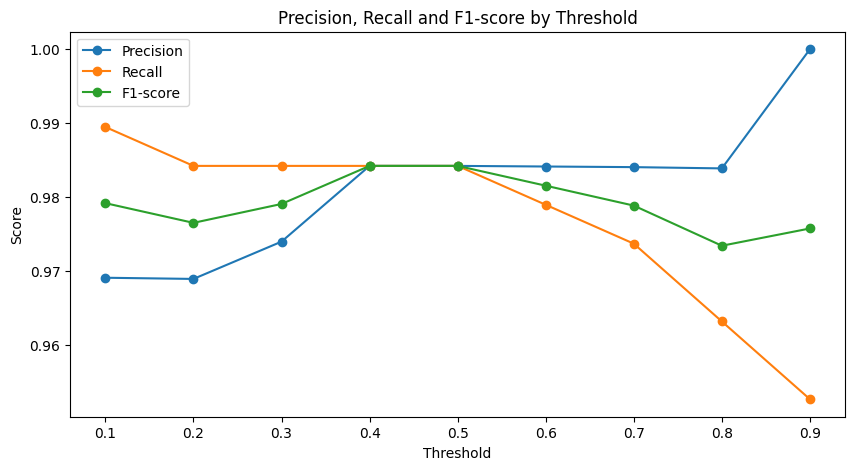

In [60]:
# 閾値ごとのPrecision・Recall・F1-scoreを可視化
plt.figure(figsize=(10, 5))

plt.plot(threshold_results_df['threshold'], threshold_results_df['precision'], marker='o', label='Precision')
plt.plot(threshold_results_df['threshold'], threshold_results_df['recall'], marker='o', label='Recall')
plt.plot(threshold_results_df['threshold'], threshold_results_df['f1_score'], marker='o', label='F1-score')

plt.title('Precision, Recall and F1-score by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

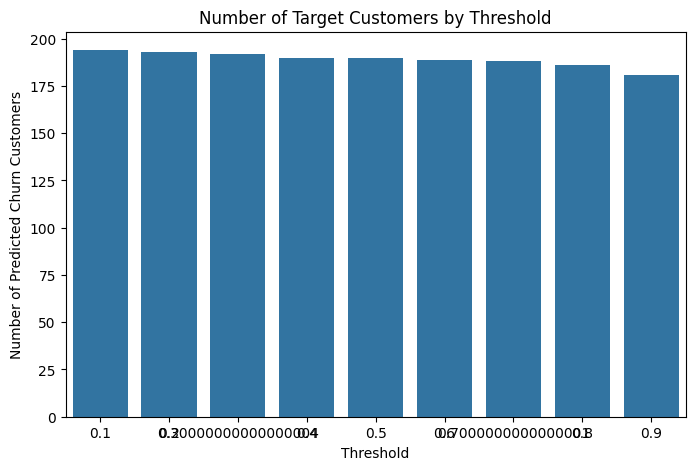

In [63]:
# 閾値ごとの施策対象人数を可視化
plt.figure(figsize=(8, 5))

sns.barplot(data=threshold_results_df, x='threshold', y='target_count')

plt.title('Number of Target Customers by Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Predicted Churn Customers')
plt.show()